# Notebook 04 — KPIs métiers (silver → indicateurs)

## Objectif

Calcul des indicateurs métiers exigés par le cahier des charges MECHA (§III.1).

## KPIs calculés

| KPI | Formule | Unité |
|---|---|---|
| **TRS** | Disponibilité × Performance × Qualité | % |
| Taux de disponibilité | `(temps_ouvert - arrets) / temps_ouvert` | % |
| Taux de performance | `pieces_produites / pieces_theoriques` | % |
| Taux de qualité | `1 - (rebuts / pieces_produites)` | % |
| Taux de rebut | `rebuts / pieces_produites` | % |
| Temps de cycle | `temps / pieces` | secondes |
| Consommation énergétique | `Torque × ω × cycle_time` | kWh |

## Rattachement grille MSPR

| Compétence | Critère |
|---|---|
| C5 — Data visualisation | Organise les données sous forme de résultats exploitables |
| C6 — Données de référence | Critères de sélection / validation des données |


## 1. Imports et chargement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

PROJECT_ROOT = Path.cwd().parent
SILVER_DIR = PROJECT_ROOT / "data" / "silver"

frames = []
for f in sorted(SILVER_DIR.glob("*.parquet")):
    frames.append(pd.read_parquet(f))

df = pd.concat(frames, ignore_index=True)
print(f"Silver total : {len(df)} pieces, {df['usine'].nunique()} usines")
print(df.groupby("usine").size())

Silver total : 10070 pieces, 2 usines
usine
ES-01    4132
FR-01    5938
dtype: int64


## 2. Paramètres de référence

Hypothèses PoC (à calibrer avec les équipes terrain) :


In [2]:
CYCLE_NOMINAL_S     = 60    # temps de cycle nominal (secondes)
SHIFT_DURATION_MIN  = 480   # duree d'un shift (8h)
PLANNED_DOWNTIME    = 30    # pauses planifiees (minutes)
ARRET_PAR_PANNE_MIN = 20    # duree d'arret moyenne par panne

print(f"Cycle nominal      : {CYCLE_NOMINAL_S} s")
print(f"Duree shift        : {SHIFT_DURATION_MIN} min")
print(f"Arret planifie     : {PLANNED_DOWNTIME} min")
print(f"Arret par panne    : {ARRET_PAR_PANNE_MIN} min")

Cycle nominal      : 60 s
Duree shift        : 480 min
Arret planifie     : 30 min
Arret par panne    : 20 min


## 3. Calcul des puissances et énergie

Puissance mécanique = Couple × vitesse angulaire
ω (rad/s) = rpm × 2π / 60


In [3]:
omega = df["Rotational speed [rpm]"] * 2 * np.pi / 60
df["puissance_w"] = df["Torque [Nm]"] * omega
df["energie_kwh"] = df["puissance_w"] * CYCLE_NOMINAL_S / 3_600_000

print("Statistiques puissance :")
print(df[["puissance_w", "energie_kwh"]].describe().round(4))

Statistiques puissance :
       puissance_w  energie_kwh
count   10070.0000   10070.0000
mean     6283.0888       0.1047
std      1193.9008       0.0199
min      -349.3872      -0.0058
25%      5558.9189       0.0926
50%      6283.5160       0.1047
75%      7010.5641       0.1168
max     18277.6587       0.3046


## 4. KPIs journaliers par usine

In [4]:
df["jour"] = pd.to_datetime(df["timestamp"]).dt.date

agg = df.groupby(["usine", "jour"]).agg(
    pieces_produites=("UDI", "count"),
    rebuts=("Machine failure", "sum"),
    twf=("TWF", "sum"),
    hdf=("HDF", "sum"),
    pwf=("PWF", "sum"),
    osf=("OSF", "sum"),
    rnf=("RNF", "sum"),
    energie_kwh=("energie_kwh", "sum"),
    torque_moyen=("Torque [Nm]", "mean"),
    temp_process_moy=("Process temperature [K]", "mean"),
    tool_wear_max=("Tool wear [min]", "max"),
).reset_index()

agg.head()

,usine,jour,pieces_produites,rebuts,twf,hdf,pwf,osf,rnf,energie_kwh,torque_moyen,temp_process_moy,tool_wear_max
0,ES-01,2025-10-01,99,5,1,0,4,0,0,10.130940,38.781154,309.935354,228
1,ES-01,2025-10-02,153,1,0,0,1,0,0,15.922392,39.530421,310.034641,246
2,ES-01,2025-10-03,133,8,1,2,1,4,1,14.196172,40.560372,310.009023,231
3,ES-01,2025-10-04,131,5,0,0,2,3,2,13.639733,39.704535,310.062595,224
4,ES-01,2025-10-05,137,4,0,2,1,1,0,14.718974,41.533676,309.933577,222


## 5. Calcul du TRS

In [5]:
# Taux qualite
agg["taux_qualite"] = 1 - (agg["rebuts"] / agg["pieces_produites"])

# Taux disponibilite
agg["arret_min"] = agg["rebuts"] * ARRET_PAR_PANNE_MIN
agg["temps_utile"] = SHIFT_DURATION_MIN - PLANNED_DOWNTIME
agg["taux_dispo"] = ((agg["temps_utile"] - agg["arret_min"]) / agg["temps_utile"]).clip(lower=0)

# Taux performance
pieces_theoriques = agg["temps_utile"] * 60 / CYCLE_NOMINAL_S
agg["taux_performance"] = (agg["pieces_produites"] / pieces_theoriques).clip(upper=1.0)

# TRS = Dispo × Perf × Qualite
agg["trs"] = agg["taux_dispo"] * agg["taux_performance"] * agg["taux_qualite"]

# Rebut (%)
agg["taux_rebut_pct"] = (agg["rebuts"] / agg["pieces_produites"] * 100).round(2)

# Energie par piece (Wh)
agg["energie_par_piece_wh"] = (agg["energie_kwh"] * 1000 / agg["pieces_produites"]).round(2)

print("\nSynthese par usine :")
print(agg.groupby("usine").agg(
    trs_moy=("trs", "mean"),
    rebut_pct=("taux_rebut_pct", "mean"),
    pieces=("pieces_produites", "sum"),
    energie_kwh=("energie_kwh", "sum"),
).round(3))


Synthese par usine :
       trs_moy  rebut_pct  pieces  energie_kwh
usine                                         
ES-01    0.234      3.149    4132      431.374
FR-01    0.289      3.478    5938      623.138


## 6. Visualisation : TRS journalier par usine

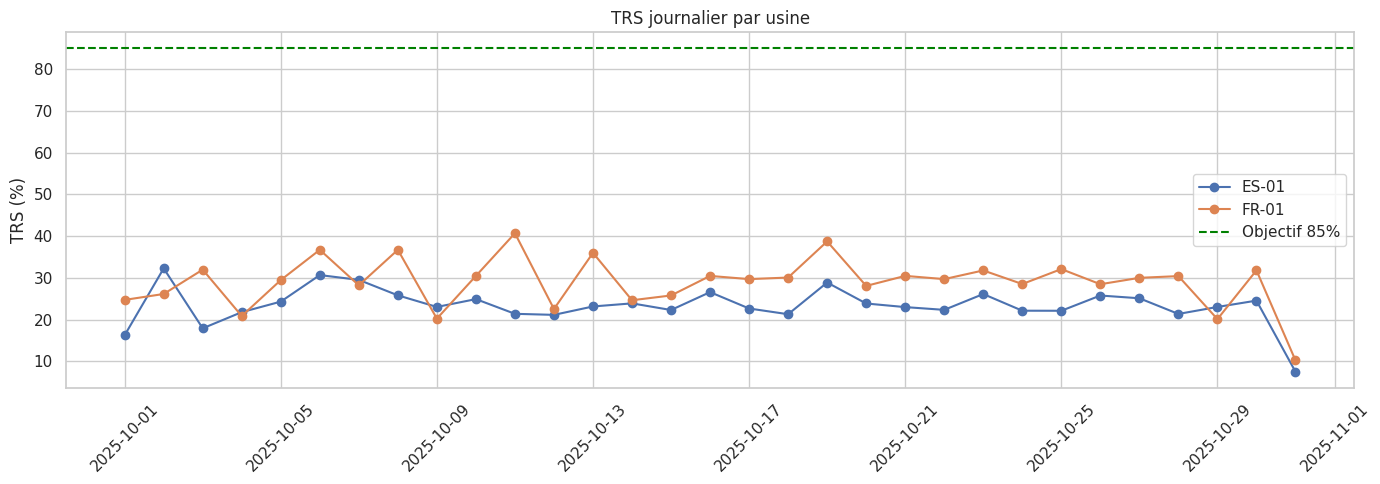

In [6]:
agg["jour"] = pd.to_datetime(agg["jour"])

fig, ax = plt.subplots(figsize=(14, 5))
for usine in agg["usine"].unique():
    sub = agg[agg["usine"] == usine].sort_values("jour")
    ax.plot(sub["jour"], sub["trs"] * 100, marker="o", label=usine)

ax.axhline(85, color="green", linestyle="--", label="Objectif 85%")
ax.set_ylabel("TRS (%)")
ax.set_title("TRS journalier par usine")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Visualisation : Taux de rebut journalier

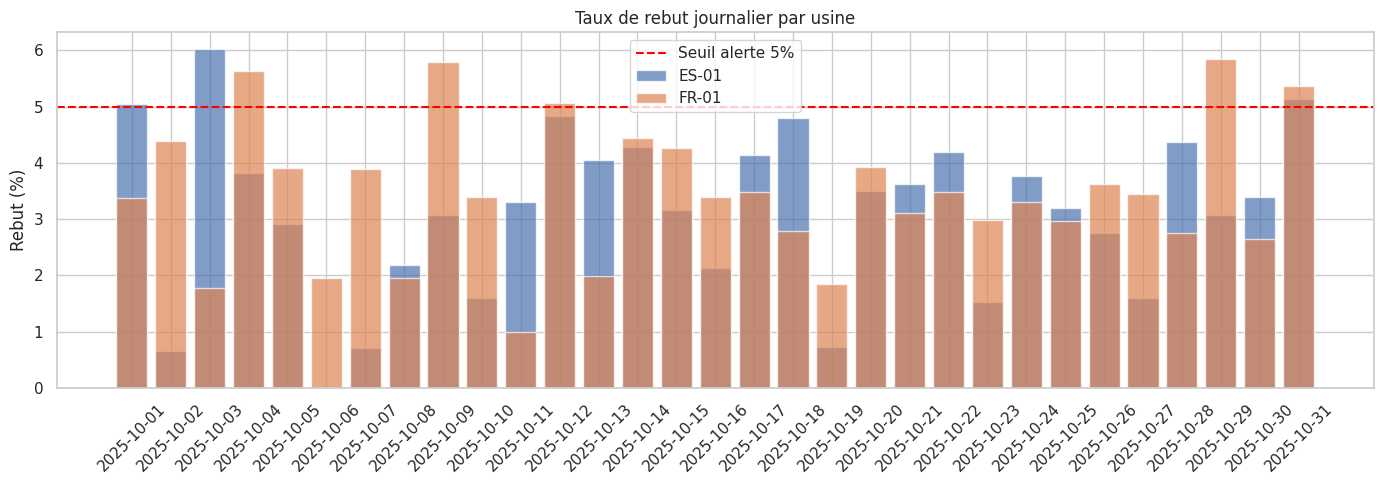

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
for usine in agg["usine"].unique():
    sub = agg[agg["usine"] == usine].sort_values("jour")
    ax.bar(sub["jour"].astype(str), sub["taux_rebut_pct"], alpha=0.7, label=usine)

ax.axhline(5, color="red", linestyle="--", label="Seuil alerte 5%")
ax.set_ylabel("Rebut (%)")
ax.set_title("Taux de rebut journalier par usine")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Benchmark inter-usines (radar)

In [8]:
bench = agg.groupby("usine").agg(
    trs_moy=("trs", "mean"),
    rebut_pct=("taux_rebut_pct", "mean"),
    pieces=("pieces_produites", "sum"),
    energie_kwh=("energie_kwh", "sum"),
    dispo=("taux_dispo", "mean"),
).reset_index()

bench["trs_moy"] = (bench["trs_moy"] * 100).round(2)
bench["dispo"] = (bench["dispo"] * 100).round(2)
print(bench)

   usine  trs_moy  rebut_pct  pieces  energie_kwh  dispo
0  ES-01    23.37   3.149355    4132   431.374170  81.65
1  FR-01    28.89   3.478065    5938   623.137572  70.75


## 9. Répartition des causes de panne

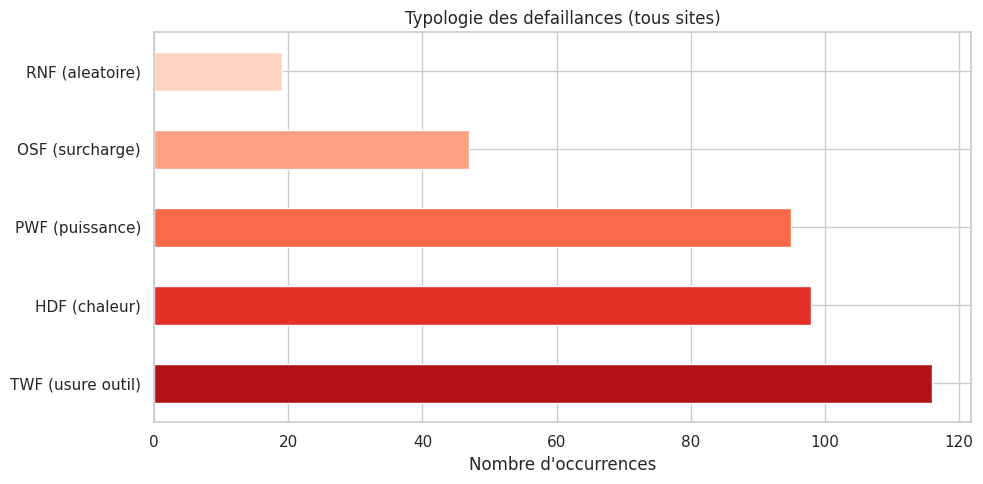

In [9]:
causes = df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum().sort_values(ascending=False)
causes.index = ["TWF (usure outil)", "HDF (chaleur)", "PWF (puissance)", "OSF (surcharge)", "RNF (aleatoire)"]

fig, ax = plt.subplots(figsize=(10, 5))
causes.plot(kind="barh", ax=ax, color=sns.color_palette("Reds_r", 5))
ax.set_title("Typologie des defaillances (tous sites)")
ax.set_xlabel("Nombre d'occurrences")
plt.tight_layout()
plt.show()

## 10. Export pour le dashboard

In [10]:
GOLD_DIR = PROJECT_ROOT / "data" / "gold"
GOLD_DIR.mkdir(parents=True, exist_ok=True)

agg.to_parquet(GOLD_DIR / "kpis_jour.parquet", index=False)

# Version horaire (utile pour alertes temps reel)
df["heure"] = pd.to_datetime(df["timestamp"]).dt.floor("h")
agg_h = df.groupby(["usine", "heure"]).agg(
    pieces=("UDI", "count"),
    rebuts=("Machine failure", "sum"),
    torque_moyen=("Torque [Nm]", "mean"),
    torque_std=("Torque [Nm]", "std"),
    tool_wear_max=("Tool wear [min]", "max"),
    temp_process_moy=("Process temperature [K]", "mean"),
    energie_kwh=("energie_kwh", "sum"),
).reset_index()
agg_h["taux_rebut_pct"] = (agg_h["rebuts"] / agg_h["pieces"] * 100).round(2)
agg_h.to_parquet(GOLD_DIR / "kpis_heure.parquet", index=False)

print(f"Export KPIs jour   : {GOLD_DIR}/kpis_jour.parquet")
print(f"Export KPIs heure  : {GOLD_DIR}/kpis_heure.parquet")

Export KPIs jour   : /home/romaric420/MSPR/data/gold/kpis_jour.parquet
Export KPIs heure  : /home/romaric420/MSPR/data/gold/kpis_heure.parquet


## 11. Synthèse

### KPIs calculés

On dispose maintenant à la granularité **journalière** et **horaire** de :

- TRS global (Disponibilité × Performance × Qualité)
- Taux de rebut, taux de disponibilité, taux de performance
- Consommation énergétique (kWh, Wh/pièce)
- Typologie des défaillances (TWF / HDF / PWF / OSF / RNF)

### Grille MSPR couverte

- **C5** : organisation des données en résultats exploitables (KPIs agrégés)
- **C6** : référentiel de données métier (définitions TRS, cycle nominal)

### Suite

- **Notebook 05** : construction de l'entrepôt multidimensionnel (étoile) dans DuckDB
